# Predicting Movie Revenue From Movie Budget

**Authors:** Audrey Vo, Roxanna Ng, Nikita Prabhu, Philip Chen

## Summary

## Introduction

### Background

### Research Question

### The Data Set

In [2]:
library(fivethirtyeight)
library(dplyr)
library(ggplot2)

Some larger datasets need to be installed separately, like senators and
house_district_forecast. To install these, we recommend you install the
fivethirtyeightdata package by running:
install.packages('fivethirtyeightdata', repos =
'https://fivethirtyeightdata.github.io/drat/', type = 'source')


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




### Loading in Data

In [3]:
data("bechdel", package = "fivethirtyeight")
write.csv(bechdel, "data/raw/raw_bechdel.csv", row.names = FALSE)

### Cleaning Data

In [4]:
movie_data <- bechdel[, c("budget", "domgross")]
head(movie_data)

budget,domgross
<int>,<dbl>
13000000,25682380
45000000,13414714
20000000,53107035
61000000,75612460
40000000,95020213
225000000,38362475


In [5]:
print(paste("# of null values (before filtering):", sum(is.na(movie_data))))

movie_data <- movie_data %>%
  filter(!is.na(budget), !is.na(domgross))

print(paste("# of null values (after filtering):", sum(is.na(movie_data))))

[1] "# of null values (before filtering): 17"
[1] "# of null values (after filtering): 0"


In [6]:
print(sum(movie_data$budget == 0))
print(sum(movie_data$domgross == 0))

[1] 0
[1] 1


In [7]:
movie_data[movie_data$domgross == 0, ]

movie_data <- movie_data %>%
  filter(budget > 0, domgross > 0)

print(sum(movie_data$budget == 0))
print(sum(movie_data$domgross == 0))

budget,domgross
<int>,<dbl>
18000000,0


[1] 0
[1] 0


## EDA

In [8]:
summary(movie_data)

     budget             domgross        
 Min.   :     7000   Min.   :      828  
 1st Qu.: 12000000   1st Qu.: 16320870  
 Median : 30000000   Median : 42239614  
 Mean   : 45174408   Mean   : 69170974  
 3rd Qu.: 60000000   3rd Qu.: 93382814  
 Max.   :425000000   Max.   :760507625  

In [9]:
str(movie_data)

tibble [1,776 × 2] (S3: tbl_df/tbl/data.frame)
 $ budget  : int [1:1776] 13000000 45000000 20000000 61000000 40000000 225000000 92000000 12000000 13000000 130000000 ...
 $ domgross: num [1:1776] 25682380 13414714 53107035 75612460 95020213 ...


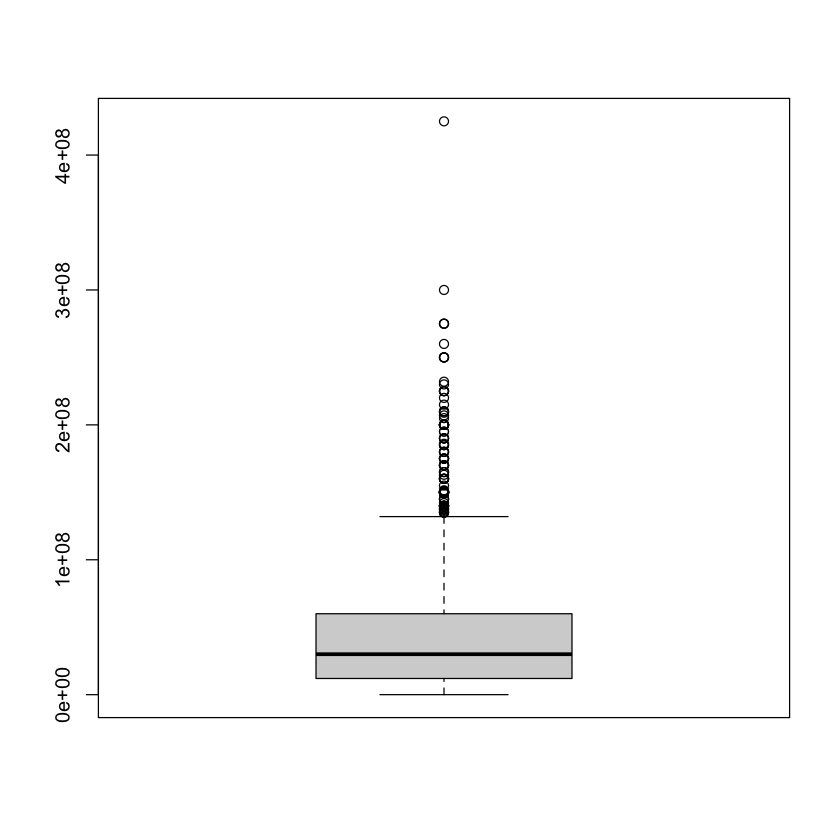

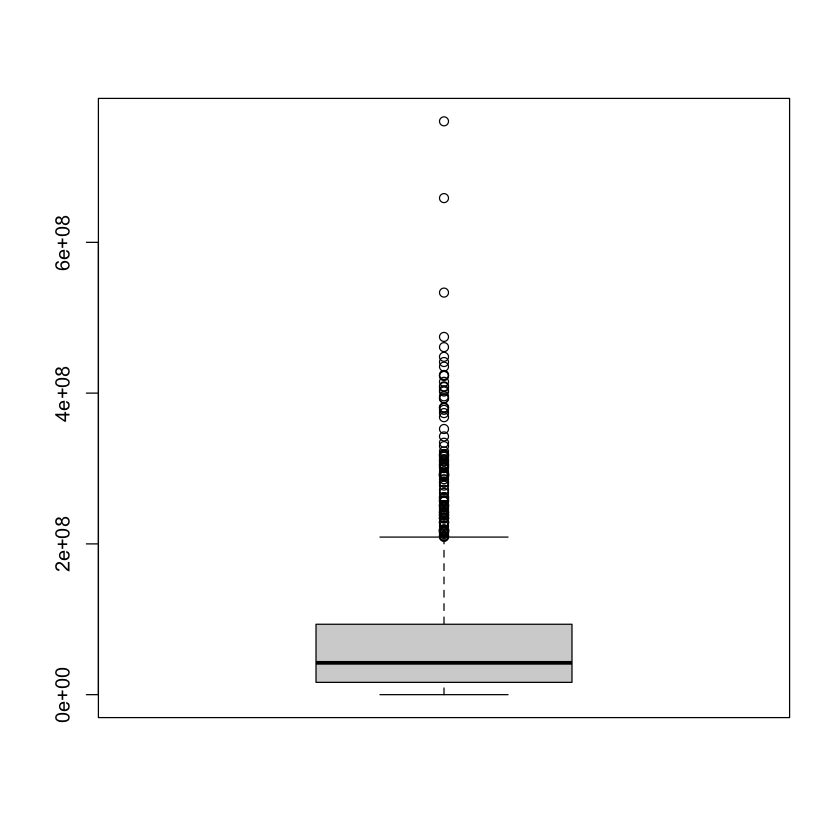

In [10]:
boxplot(movie_data$budget)
boxplot(movie_data$domgross)

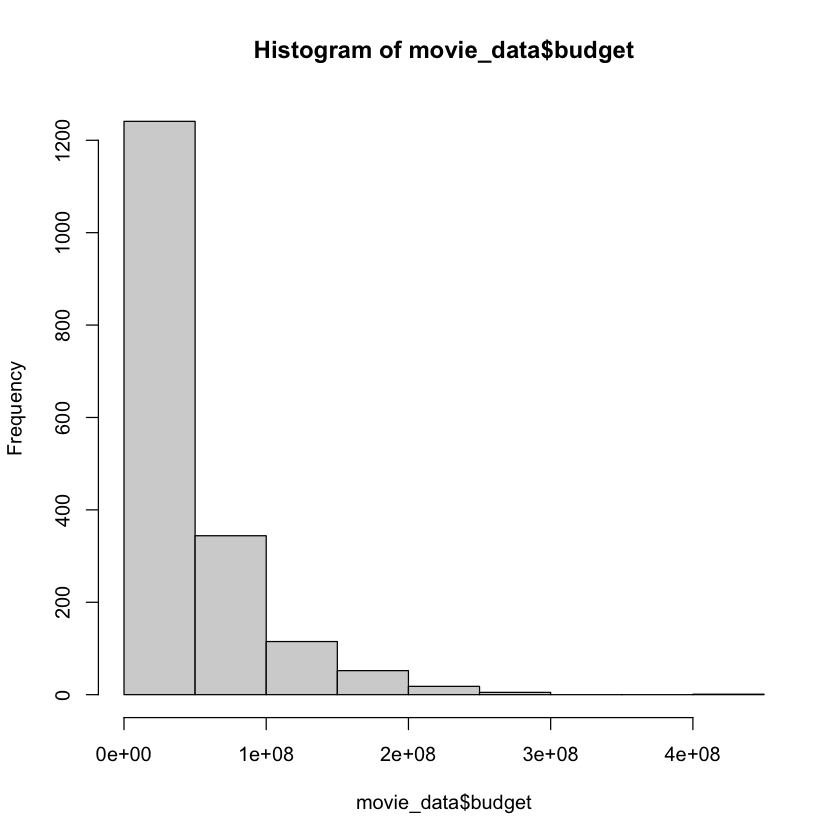

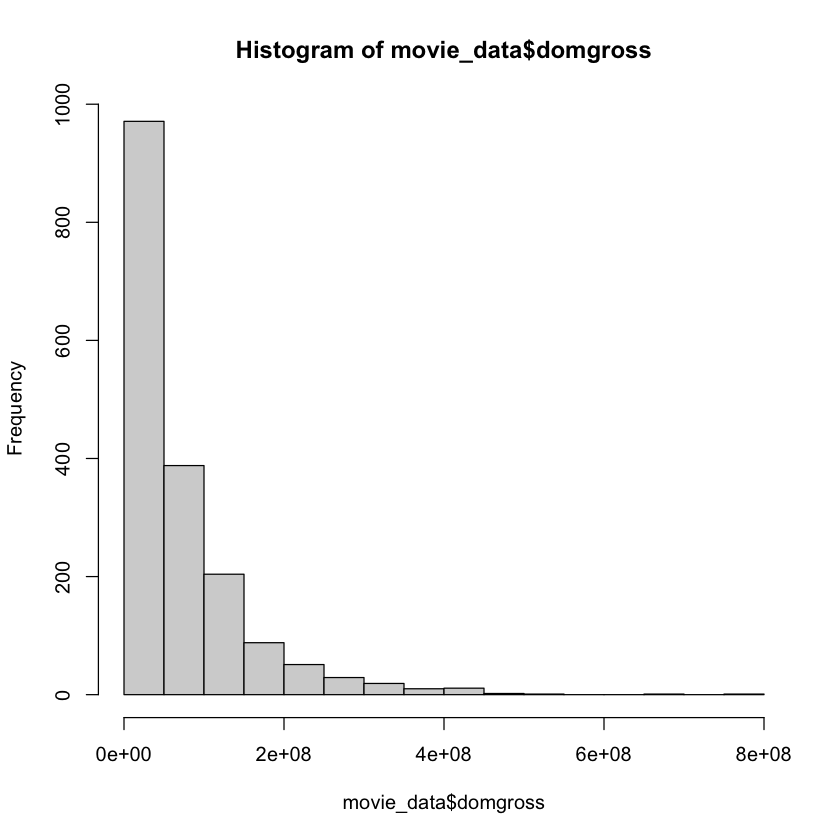

In [11]:
hist(movie_data$budget)
hist(movie_data$domgross)

`geom_smooth()` using formula = 'y ~ x'


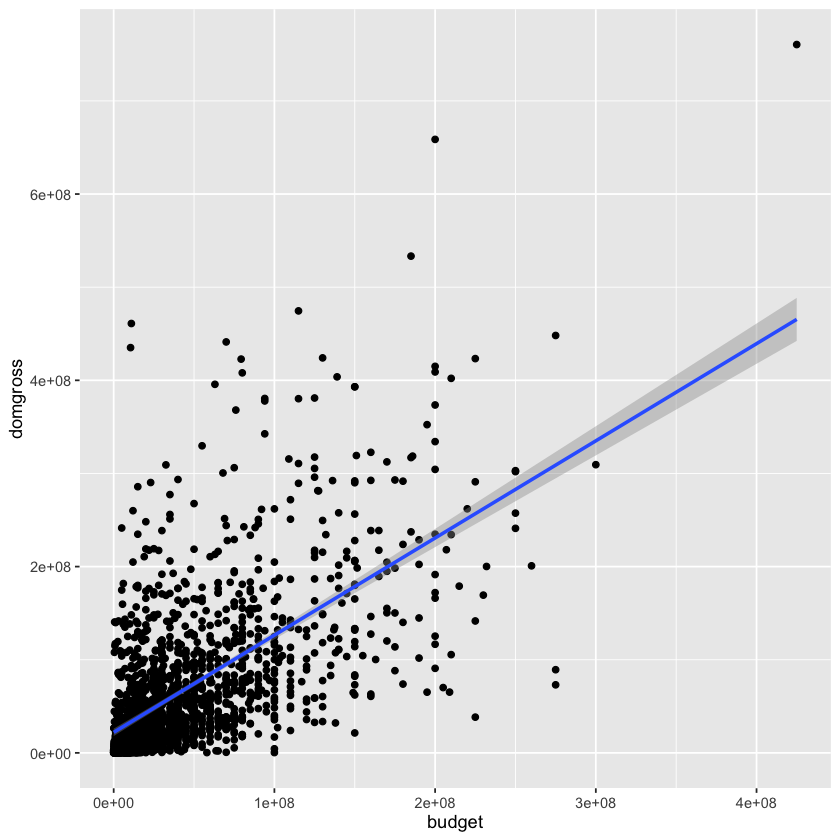

In [12]:
budget_rev_plot <- ggplot(movie_data, aes(x = budget, y = domgross)) +
  geom_point() +
  geom_smooth(method = "lm")
budget_rev_plot

In [13]:
cor(movie_data$budget, movie_data$domgross)

[1] 0.6268848

`geom_smooth()` using formula = 'y ~ x'


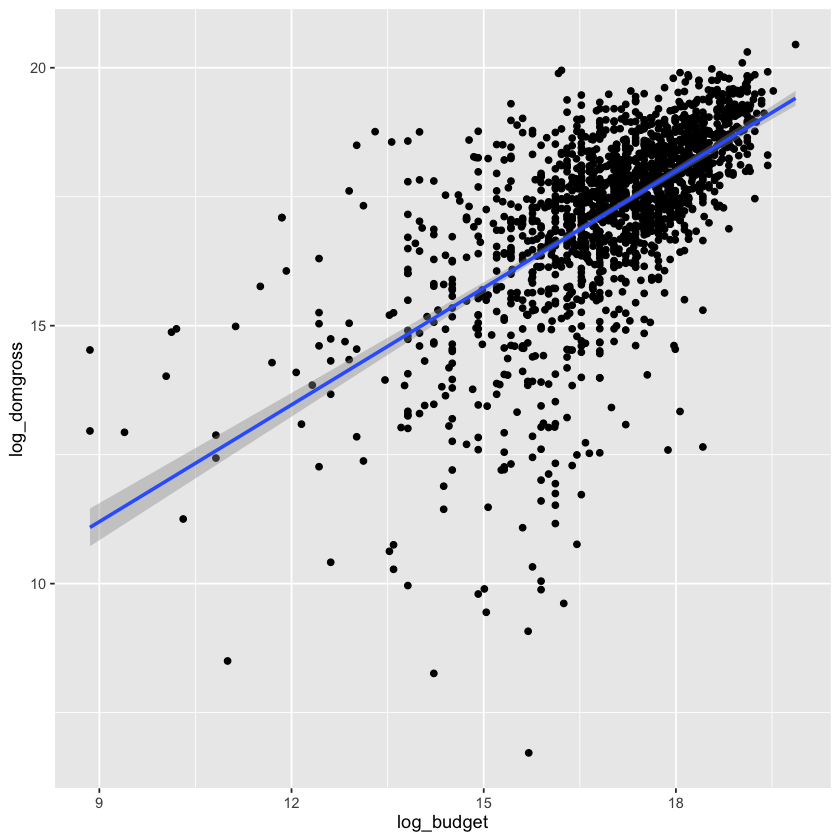

In [14]:
movie_data <- movie_data %>% 
  mutate(log_budget = log(budget), log_domgross = log(domgross))

log_budget_rev_plot <- ggplot(movie_data, aes(x = log_budget, y = log_domgross)) +
  geom_point() +
  geom_smooth(method = "lm")
log_budget_rev_plot

In [16]:
head(movie_data)
write.csv(movie_data, "data/processed/clean_bechdel.csv", row.names = FALSE)

budget,domgross,log_budget,log_domgross
<int>,<dbl>,<dbl>,<dbl>
13000000,25682380,16.38046,17.06132
45000000,13414714,17.62217,16.41186
20000000,53107035,16.81124,17.78782
61000000,75612460,17.92638,18.14113
40000000,95020213,17.50439,18.36960
225000000,38362475,19.23161,17.46259


## Methods and Results